# Using Data to inform game design changes
<hr>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import requests
import seaborn as sns
from sklearn.linear_model import LinearRegression
import Data_Functions as dh

In [2]:
powerup_df = dh.read_powerup_data()

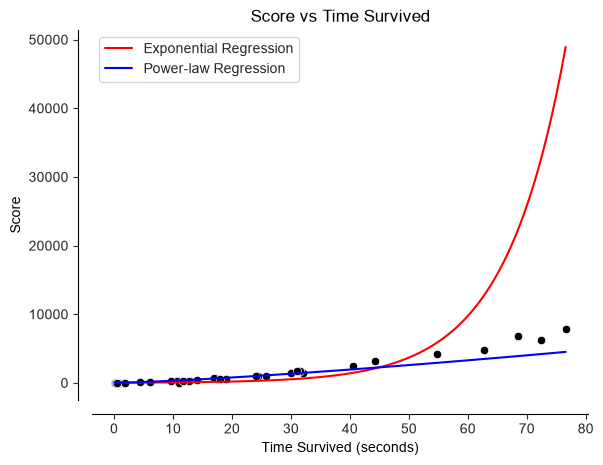

Exponential:   Score = 28.49 * exp(0.097250 * Time Survived)
Exponential R²: 0.739
Power-law:   Score = 16.22 × Time Survived^1.30
Power-law R²:   0.975


In [3]:
gr_df = dh.read_results()


dh.score_over_time(data=gr_df)

In [4]:
merged_df = dh.powerup_gr_merge(powerup_df,gr_df)
merged_df.head()

,Powerup,Time Spawned,Time Activated,Time Effect Ended,Game Version,Time Survived,Score,Survival Group,Score Group,Time Survived After Activated
Date,,,,,,,,,,
2026-08-20 19:53:15.689284,Eat_Enemy_Powerup,22.549473,25.925230,30.938932,2026-08-19 16:09:37.386632,54.742633,4164,30 < 59,1000 < 4999,28.817402
2026-08-20 19:53:15.689284,Eat_Enemy_Powerup,45.070239,45.870412,50.875540,2026-08-19 16:09:37.386632,54.742633,4164,30 < 59,1000 < 4999,8.872221
2026-08-20 19:53:15.689284,Score_Increase_Powerup,15.043289,15.925274,20.856675,2026-08-19 16:09:37.386632,54.742633,4164,30 < 59,1000 < 4999,38.817358
2026-08-20 19:53:15.689284,Score_Increase_Powerup,30.052839,30.883667,35.842999,2026-08-19 16:09:37.386632,54.742633,4164,30 < 59,1000 < 4999,23.858966
2026-08-20 19:53:15.689284,Temp_Change_Colour_Powerup,7.528527,NaN,NaN,2026-08-19 16:09:37.386632,54.742633,4164,30 < 59,1000 < 4999,NaN


## Filtering by Game Version
<hr>
dh.split_game_version can either split a df into a separate df for each game version.<br>
Or it can return a df of a single game version<br>
Or it can return a df of of a list of game versions

In [5]:
dfs, version_map = dh.split_game_version(gr_df.copy())
dfs[3]

,Time Survived,Score,Survival Group,Score Group
Date,,,,
2026-08-20 15:49:02.085876,0.662901,11,0 < 4,0 < 99
2026-08-20 15:49:02.085876,0.662901,11,0 < 4,0 < 99
2026-08-20 19:04:30.613762,0.116541,1,0 < 4,0 < 99
2026-08-20 19:07:07.897435,0.552560,9,0 < 4,0 < 99
2026-08-20 19:34:07.238980,0.005996,0,0 < 4,0 < 99
2026-08-20 19:35:20.432343,0.219969,3,0 < 4,0 < 99
2026-08-20 19:38:26.656771,6.137717,123,5 < 9,100 < 499
2026-08-20 19:38:47.996052,0.665038,11,0 < 4,0 < 99
2026-08-20 19:39:35.510349,1.932754,35,0 < 4,0 < 99


Single Game Version can be called by what number game version it is or using the datetime itself

In [6]:
new_df = dh.split_game_version(gr_df, 3)
str(new_df.index.dtype)

'datetime64[us]'

List of Game Versions

In [7]:
new_df = dh.split_game_version(gr_df, [1,2,3])

print(f"Number of Game Results: {len(gr_df)}\nNumber of Game Results (Game Version 1,2,3): {len(new_df)}")


Number of Game Results: 44
Number of Game Results (Game Version 1,2,3): 44


## Getting Charts from our new dataframes
<hr>

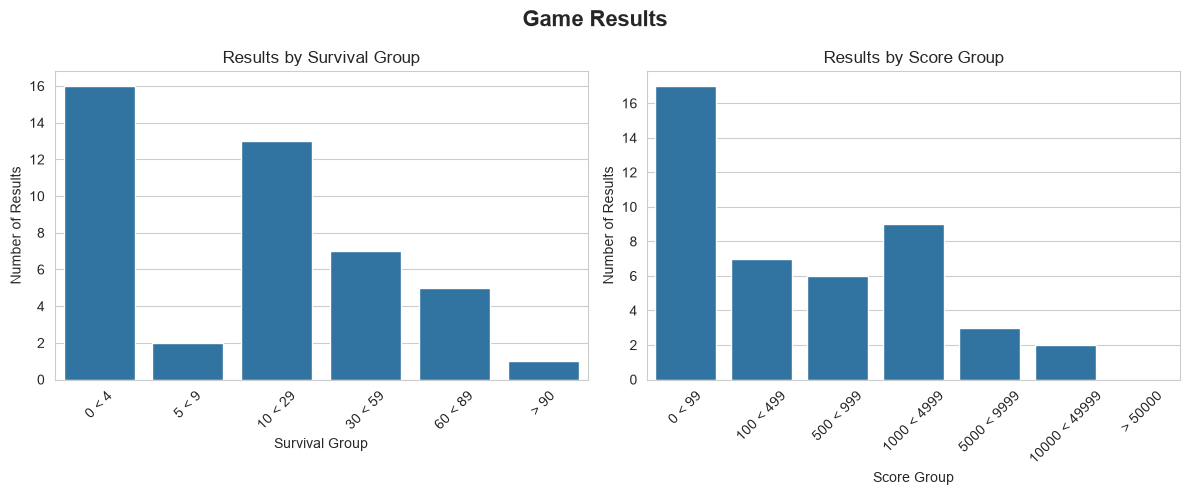

In [8]:
dh.bar_charts(data=new_df)